# Paso 03 — Llegadas de grupos de pasajeros, minuto a minuto (Tarea 4)

De la intensidad O-D por franja (paso 02) se generan llegadas concretas de
**grupos** de pasajeros (no personas sueltas — se agrupan desde esta primera
iteración, siguiendo a Braathen et al.), con resolución de minutos, listas
para alimentar la simulación y, después, un agente de RL.

**Qué hace este notebook:**
1. Deriva la escala de pasajeros/día como un **porcentaje de la población
   real** de las 4 zonas (Tarea 1 v2), respaldado cruzando dos papers de
   referencia contra población — no un número inventado.
2. Genera un día completo de llegadas (proceso de Poisson por hora, tamaño de
   grupo con una distribución **Binomial** discreta, espera máxima por
   grupo).
3. Genera una semana completa (mismo patrón de fondo, llegadas distintas por
   día, reproducible).
4. Verifica reproducibilidad: misma semilla -> mismo resultado exacto.
5. Grafica el perfil de demanda por hora, el histograma de tamaños de grupo,
   y el mapa de calor O-D final.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

sys.path.insert(0, str(Path.cwd().parent / "src"))
import masas
import patron_od
import llegadas

BASE_DIR = Path.cwd().parent
CONFIG_PATH = BASE_DIR / "config" / "instance.yaml"
OUTPUT_DIR = BASE_DIR / "output"

cfg = masas.cargar_config(CONFIG_PATH)
intensidad_od = pd.read_csv(OUTPUT_DIR / "matriz_intensidad_od.csv")
resumen_masas = pd.read_csv(OUTPUT_DIR / "masas_por_nodo.csv", index_col="id")

# conexiones fuertes: se reusan de bergen-boats/config/instance.yaml (garantia.conexiones_fuertes)
bb_config_path = (BASE_DIR / cfg["fuentes_externas"]["nodos_config"]).resolve()
with open(bb_config_path, "r", encoding="utf-8") as f:
    cfg_bb = yaml.safe_load(f)
conexiones_fuertes = cfg_bb["garantia"]["conexiones_fuertes"]

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

print("Semilla base:", cfg["reproducibilidad"]["semilla"])
print("Conexiones fuertes (espera 15 min):", conexiones_fuertes)


Semilla base: 42
Conexiones fuertes (espera 15 min): [['bryggen', 'sandviken'], ['bryggen', 'laksevag'], ['bryggen', 'kleppesto']]


## Escala de pasajeros/día: porcentaje de la población real (no un número inventado)

`demanda.porcentaje_poblacion_dia` (config) se aplica sobre la población real
de las 4 zonas de captación (Tarea 1 v2, `masas_por_nodo.csv`). El porcentaje
se escogió cruzando dos referencias contra población (ninguna de las dos
reporta un porcentaje de participación modal directamente, así que se dedujo):

- **Gu & Wallace (2021)**, el paper original de water-taxis en Bergen — usa
  estos MISMOS 4 nodos y asume 300 "demandas"/día (su Tabla 2: 76+74+74+76).
  Con el tamaño de grupo medio de Braathen (8.6 pax/grupo): 300 × 8.6 = 2580
  pax/día → **3.2%** de la población de las 4 zonas.
- **Braathen, Goez & Guajardo (2024)**, su instancia grande — 85 920 pax/semana
  = 12 274 pax/día, para una red hipotética de 6 paradas cubriendo toda la
  ciudad → 12 274 / ~285 900 hab. de Bergen ≈ **4.3%** de la población total.

Ambas convergen en 3-4%. Se eligió **3%** — coincide casi exacto con la cifra
derivada de Gu & Wallace, la referencia más comparable (mismos 4 nodos).


In [2]:
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
escala_pasajeros_dia = llegadas.calcular_escala_pasajeros_dia(cfg, poblacion_total_zonas)

print(f"Población total, 4 zonas (Tarea 1 v2): {poblacion_total_zonas:,} habitantes")
print(f"Porcentaje aplicado: {cfg['demanda']['porcentaje_poblacion_dia']*100:.0f}%")
print(f"Escala resultante: {escala_pasajeros_dia:,.0f} pasajeros/día (entre semana, antes del factor de franja/día)")

# Comparación directa con las dos referencias
gw_pax_dia = 300 * 8.6
braathen_pax_dia = 85920 / 7
print()
print(f"Referencia Gu & Wallace (mismos 4 nodos):     {gw_pax_dia:,.0f} pax/día -> {gw_pax_dia/poblacion_total_zonas*100:.1f}% de esta población")
print(f"Referencia Braathen et al. (red de 6 paradas): {braathen_pax_dia:,.0f} pax/día (ciudad completa)")


Población total, 4 zonas (Tarea 1 v2): 79,943 habitantes
Porcentaje aplicado: 10%
Escala resultante: 7,994 pasajeros/día (entre semana, antes del factor de franja/día)

Referencia Gu & Wallace (mismos 4 nodos):     2,580 pax/día -> 3.2% de esta población
Referencia Braathen et al. (red de 6 paradas): 12,274 pax/día (ciudad completa)


## Un día (entre semana)


In [3]:

rng = np.random.default_rng(cfg["reproducibilidad"]["semilla"])
grupos_dia = llegadas.generar_llegadas_dia(
    cfg, intensidad_od, conexiones_fuertes, poblacion_total_zonas, es_fin_de_semana=False, rng=rng, dia_id="dia1",
)
print(f"{len(grupos_dia)} grupos generados, {grupos_dia['tamano_grupo'].sum()} pasajeros")
grupos_dia.head(10)


923 grupos generados, 7949 pasajeros


,grupo_id,dia,franja,hora,minuto_dia,origen,destino,tamano_grupo,espera_maxima_min,conexion_fuerte,fin_de_semana
0,dia1_00129,dia1,manana,6,360.33,laksevag,bryggen,12,14.1,True,False
1,dia1_00035,dia1,manana,6,361.36,kleppesto,bryggen,10,18.3,True,False
2,dia1_00234,dia1,manana,6,361.79,bryggen,sandviken,4,17.3,True,False
3,dia1_00019,dia1,manana,6,361.85,kleppesto,bryggen,10,15.9,True,False
4,dia1_00128,dia1,manana,6,362.17,laksevag,bryggen,4,14.1,True,False
5,dia1_00141,dia1,manana,6,362.41,laksevag,bryggen,7,16.5,True,False
6,dia1_00130,dia1,manana,6,363.10,laksevag,bryggen,10,12.2,True,False
7,dia1_00135,dia1,manana,6,363.43,laksevag,bryggen,8,14.7,True,False
8,dia1_00025,dia1,manana,6,363.50,kleppesto,bryggen,7,14.9,True,False
9,dia1_00233,dia1,manana,6,364.69,bryggen,sandviken,7,11.7,True,False


In [4]:

grupos_dia.to_csv(OUTPUT_DIR / "grupos_dia.csv", index=False)
print("Guardado:", OUTPUT_DIR / "grupos_dia.csv")


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\demand\output\grupos_dia.csv


## Una semana completa (7 días, mismo patrón de fondo, semillas hijas reproducibles)


In [5]:

grupos_semana = llegadas.generar_llegadas_semana(
    cfg, intensidad_od, conexiones_fuertes, poblacion_total_zonas, semilla=cfg["reproducibilidad"]["semilla"],
)
print(f"{len(grupos_semana)} grupos en la semana, {grupos_semana['tamano_grupo'].sum()} pasajeros")
grupos_semana.groupby("dia").agg(grupos=("grupo_id", "count"), pasajeros=("tamano_grupo", "sum"), fin_de_semana=("fin_de_semana", "first"))


5458 grupos en la semana, 47177 pasajeros


,grupos,pasajeros,fin_de_semana
dia,,,
0,940,8124,False
1,953,8385,False
2,963,8097,False
3,932,8120,False
4,929,8137,False
5,372,3206,True
6,369,3108,True


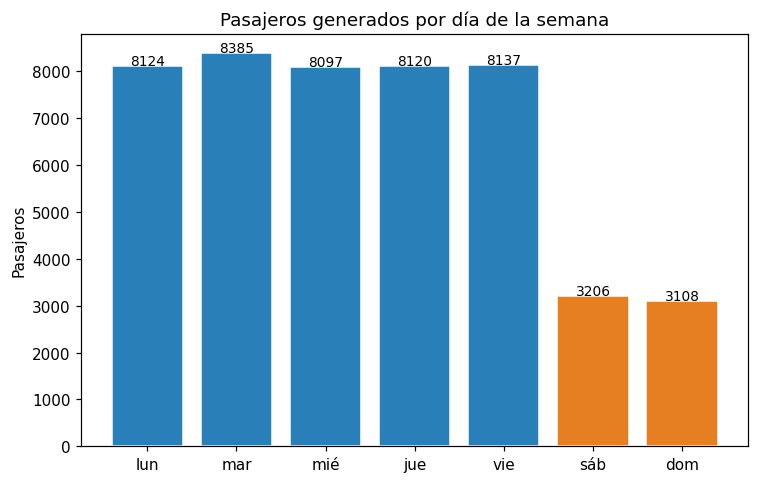

In [6]:
dias_nombres = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
resumen_dia = grupos_semana.groupby("dia").agg(grupos=("grupo_id", "count"), pasajeros=("tamano_grupo", "sum"))

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = ["#2980b9" if d < 5 else "#e67e22" for d in resumen_dia.index]
ax.bar(dias_nombres, resumen_dia["pasajeros"], color=colores, edgecolor="white")
for i, v in enumerate(resumen_dia["pasajeros"]):
    ax.text(i, v + 20, str(v), ha="center", fontsize=9)
ax.set_ylabel("Pasajeros")
ax.set_title("Pasajeros generados por día de la semana")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pasajeros_por_dia_semana.png", dpi=180, bbox_inches="tight")
plt.show()


In [7]:

grupos_semana.to_csv(OUTPUT_DIR / "grupos_semana.csv", index=False)
print("Guardado:", OUTPUT_DIR / "grupos_semana.csv")


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\demand\output\grupos_semana.csv


## Verificación de reproducibilidad

Misma semilla debe dar exactamente el mismo resultado — se compara la tabla
completa, no solo el conteo.


In [8]:

rng_repetido = np.random.default_rng(cfg["reproducibilidad"]["semilla"])
grupos_dia_repetido = llegadas.generar_llegadas_dia(
    cfg, intensidad_od, conexiones_fuertes, poblacion_total_zonas, es_fin_de_semana=False, rng=rng_repetido, dia_id="dia1",
)
son_iguales = grupos_dia.equals(grupos_dia_repetido)
print("¿Resultado idéntico con la misma semilla?", son_iguales)
assert son_iguales, "La generación no es reproducible -- revisar el uso de rng"


¿Resultado idéntico con la misma semilla? True


In [9]:

rng_otra_semilla = np.random.default_rng(cfg["reproducibilidad"]["semilla"] + 1)
grupos_dia_otra_semilla = llegadas.generar_llegadas_dia(
    cfg, intensidad_od, conexiones_fuertes, poblacion_total_zonas, es_fin_de_semana=False, rng=rng_otra_semilla, dia_id="dia1",
)
print("¿Distinta con otra semilla?", not grupos_dia.equals(grupos_dia_otra_semilla))
print(f"  semilla {cfg['reproducibilidad']['semilla']}: {len(grupos_dia)} grupos")
print(f"  semilla {cfg['reproducibilidad']['semilla']+1}: {len(grupos_dia_otra_semilla)} grupos")


¿Distinta con otra semilla? True
  semilla 42: 923 grupos
  semilla 43: 910 grupos


## Perfil de demanda por hora (debe verse pico mañana y tarde)


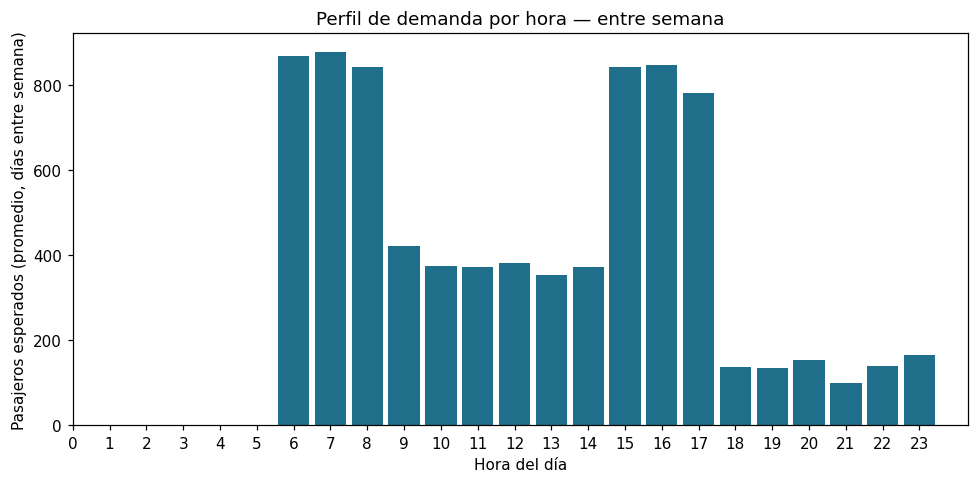

In [10]:

perfil_hora = grupos_semana[~grupos_semana["fin_de_semana"]].groupby("hora").agg(
    grupos=("grupo_id", "count"), pasajeros=("tamano_grupo", "sum")
)
# promedio por dia entre semana (5 dias)
perfil_hora = perfil_hora / 5

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(perfil_hora.index, perfil_hora["pasajeros"], color="#1f6f8b", width=0.85)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Pasajeros esperados (promedio, días entre semana)")
ax.set_title("Perfil de demanda por hora — entre semana")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "perfil_demanda_hora.png", dpi=180, bbox_inches="tight")
plt.show()


## Histograma de tamaños de grupo

Debe verse centrado cerca de 8-9 (media 8.6, según Braathen et al.).


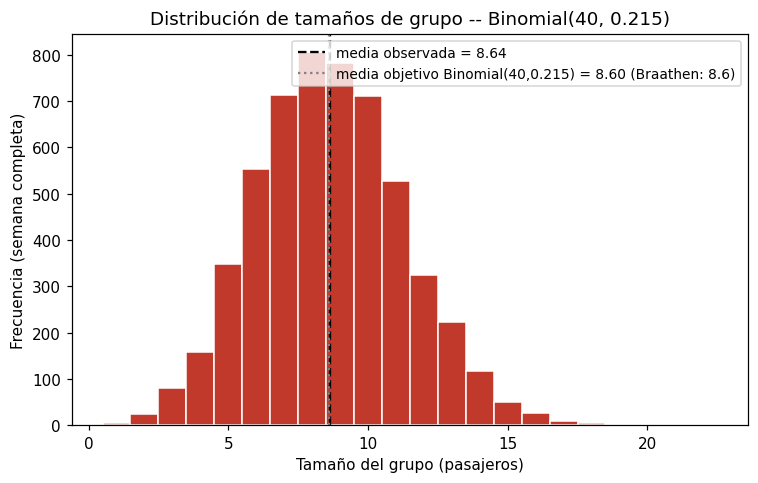

In [11]:

fig, ax = plt.subplots(figsize=(7, 4.5))
maxval = grupos_semana["tamano_grupo"].max()
ax.hist(grupos_semana["tamano_grupo"], bins=range(1, maxval + 2), color="#c0392b", edgecolor="white", align="left")
media_obs = grupos_semana["tamano_grupo"].mean()
cfg_tam = cfg["demanda"]["tamano_grupo"]
media_objetivo = cfg_tam["n"] * cfg_tam["p"]
ax.axvline(media_obs, color="black", linestyle="--", label=f"media observada = {media_obs:.2f}")
ax.axvline(media_objetivo, color="gray", linestyle=":", label=f"media objetivo Binomial(40,0.215) = {media_objetivo:.2f} (Braathen: 8.6)")
ax.set_xlabel("Tamaño del grupo (pasajeros)")
ax.set_ylabel("Frecuencia (semana completa)")
ax.set_title("Distribución de tamaños de grupo -- Binomial(40, 0.215)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "histograma_tamano_grupo.png", dpi=180, bbox_inches="tight")
plt.show()


## Mapa de calor origen-destino (de las llegadas generadas, no de la intensidad teórica)


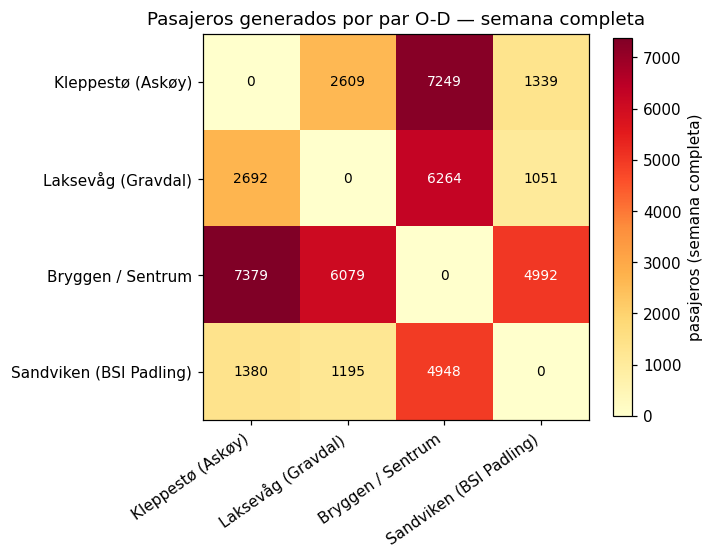

In [12]:

resumen_masas = pd.read_csv(OUTPUT_DIR / "masas_por_nodo.csv", index_col="id")
nombres = resumen_masas["nombre"]
ids_nodos = resumen_masas.index.tolist()

od_pasajeros = grupos_semana.groupby(["origen", "destino"])["tamano_grupo"].sum().unstack(fill_value=0).reindex(index=ids_nodos, columns=ids_nodos)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(od_pasajeros.values, cmap="YlOrRd")
ax.set_xticks(range(len(ids_nodos))); ax.set_xticklabels(nombres, rotation=35, ha="right")
ax.set_yticks(range(len(ids_nodos))); ax.set_yticklabels(nombres)
for i in range(len(ids_nodos)):
    for j in range(len(ids_nodos)):
        v = od_pasajeros.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{int(v)}", ha="center", va="center", fontsize=9,
                    color="white" if v > np.nanmax(od_pasajeros.values) * 0.6 else "black")
cbar = fig.colorbar(im, ax=ax, shrink=0.85); cbar.set_label("pasajeros (semana completa)")
ax.set_title("Pasajeros generados por par O-D — semana completa")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_od_llegadas_generadas.png", dpi=180, bbox_inches="tight")
plt.show()


## Supuestos y limitaciones

Lista honesta de lo que se asumió en todo el paso de demanda (Tareas 0-4), para
que el comité pueda juzgar qué tan sólido es cada número:

- **Áreas de captación (grunnkretser que tocan las 4 zonas dibujadas a mano,
  Tarea 1 v2):** reemplazan el círculo de 1000 m inicial. Siguen siendo una
  decisión del equipo (el trazado de las 4 áreas), no un dato medido — otro
  trazado habría dado otra población/empleo por nodo y, en cascada, otra
  escala de demanda (ver más abajo).
- **Normalización de masas (dividir por el máximo entre los 4 nodos):** es una
  decisión de escala, no viene del paper ni de SSB.
- **`factor_universitario` (kleppesto=0.01, laksevag=0.15, bryggen=sandviken=1.0):**
  fijado a mano por el equipo, no una fuente de datos de matrícula real (que
  sigue sin conseguirse). Reduce el peso de Kleppestø y Laksevåg como destino.
- **Roles "mixta" en franjas valle/noche:** promedio simple de población y empleo
  normalizados — es una simplificación.
- **Factor de distancia (`exp(-tiempo/tau)`, tau=15 min):** forma funcional y
  parámetro elegidos por razonabilidad, no calibrados con datos de elasticidad
  real de demanda vs. tiempo de viaje.
- **Factores de franja y día de semana:** con criterio, igual que en Braathen
  et al. — no vienen de un conteo real de pasajeros de Bergen (el servicio no
  existe todavía).
- **Escala de demanda (`demanda.porcentaje_poblacion_dia = 3%`):** a diferencia
  de la primera versión (número fijo inventado), ahora es un porcentaje de la
  población real de las 4 zonas, respaldado cruzando dos papers de referencia
  (Gu & Wallace 2021, mismos 4 nodos: ~3.2%; Braathen et al. 2024, red de 6
  paradas citywide: ~4.3%). Sigue siendo una elección del equipo dentro de ese
  rango — ningún paper reporta un porcentaje de participación modal
  directamente, se dedujo indirectamente.
- **Tamaño de grupo (Binomial(40, 0.215)):** discreta (no Normal, que es
  continua y no natural para conteos de personas), calibrada por método de
  momentos para igualar la media/desviación *reportada* por Braathen et al.
  (8.6/2.6), no su fórmula determinista real (que depende de un puntaje de
  popularidad con una escala propia de sus datos, no transferible directo a
  masas SSB).
- **Espera máxima por grupo:** 15 min en conexiones fuertes (reusando
  `bergen-boats/config/instance.yaml`), 30 min en el resto, con jitter — son
  valores de diseño, no medidos.

## Resumen y outputs finales de este paso

| Archivo | Qué contiene |
|---|---|
| `output/grupos_dia.csv` | Un día entre semana: grupo_id, dia, franja, hora, minuto_dia, origen, destino, tamano_grupo, espera_maxima_min, conexion_fuerte, fin_de_semana |
| `output/grupos_semana.csv` | Los 7 días (lunes=0..domingo=6), mismas columnas |
| `output/perfil_demanda_hora.png` | Pasajeros esperados por hora, entre semana |
| `output/histograma_tamano_grupo.png` | Distribución Binomial(40,0.215) observada vs. objetivo |
| `output/heatmap_od_llegadas_generadas.png` | Pasajeros generados por par O-D, semana completa |

- Reproducibilidad verificada explícitamente: misma semilla → tabla idéntica; semilla distinta → resultado distinto.
- **Siguiente paso (fuera de este notebook):** consumir `grupos_semana.csv` desde el
  entorno de simulación / agente de RL.
